# Homework 03: Machine Learning for Classification

**Course:** Machine Learning Zoomcamp (2026 Cohort)  
**Author:** Wisnu Anugrah Pratama  
**GitHub:** [@wapratama](https://github.com/wapratama)

---

### Overview
This notebook contains my solutions and technical write-up for **Homework 03: Machine Learning for Classification** as part of the [Machine Learning Zoomcamp](https://github.com/DataTalksClub/machine-learning-zoomcamp) by DataTalksClub.

### **Download the Dataset**
Download the official **2026 Car Fuel Efficiency** dataset directly into your `data/` directory

In [1]:
!curl -o ../data/course_lead_scoring_2026.csv https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
100 278746 100 278746   0     0 306873     0  --:--:-- --:--:-- --:--:-- 308688


### Data preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For categorical features, replace them with 'NA'
    * For numerical features, replace with with 0.0 

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../data/course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [8]:
df.describe(include='all')

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,4852,4760,4806,4792,4631.000000,5000.000000,5000.000000,4965.000000,5000.000000
unique,5,6,4,5,NaN,NaN,NaN,NaN,NaN
top,organic_search,technology,employed,north_america,NaN,NaN,NaN,NaN,NaN
freq,1251,1173,2633,1371,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,54533.212049,2.089400,4.472600,0.494767,0.576600
std,NaN,NaN,NaN,NaN,21245.661710,1.188987,2.435906,0.199431,0.494147
min,NaN,NaN,NaN,NaN,12000.000000,0.000000,0.000000,0.010000,0.000000
25%,NaN,NaN,NaN,NaN,40458.500000,1.000000,3.000000,0.360000,0.000000
50%,NaN,NaN,NaN,NaN,55051.000000,2.000000,4.000000,0.490000,1.000000
75%,NaN,NaN,NaN,NaN,71252.500000,3.000000,6.000000,0.630000,1.000000


In [9]:
# Function to display information about missing value
def show_null(df):
    """
    Return the total missing values and the percentage of
    missing values by column.
    """
    null_count = df.isnull().sum()
    null_percentage = (null_count / df.shape[0]) * 100
    empty_count = pd.Series(((df == ' ') | (df == '')).sum())
    empty_percentage = (empty_count / df.shape[0]) * 100
    nan_count = pd.Series(((df == 'nan') | (df == 'NaN') | (df == np.nan)).sum())
    nan_percentage = (nan_count / df.shape[0]) * 100
    return pd.DataFrame({'num_missing': null_count,
                         'missing_percentage': null_percentage,
                         'num_empty': empty_count,
                         'empty_percentage': empty_percentage,
                         'nan_count': nan_count,
                         'nan_percentage': nan_percentage})

show_null(df)

,num_missing,missing_percentage,num_empty,empty_percentage,nan_count,nan_percentage
lead_source,148,2.96,0,0.0,0,0.0
industry,240,4.80,0,0.0,0,0.0
employment_status,194,3.88,0,0.0,0,0.0
location,208,4.16,0,0.0,0,0.0
annual_income,369,7.38,0,0.0,0,0.0
number_of_courses_viewed,0,0.00,0,0.0,0,0.0
interaction_count,0,0.00,0,0.0,0,0.0
lead_score,35,0.70,0,0.0,0,0.0
converted,0,0.00,0,0.0,0,0.0


In [10]:
# Classify Data
target = 'converted'
categorical = list(df.select_dtypes(include=['object']).columns)
numerical = list(df.select_dtypes(include=['int64', 'float64']).columns)

if target in numerical:
    numerical.remove(target)

# Impute missing values
for col in categorical:
    df[col] = df[col].fillna('NA')

for col in numerical:
    df[col] = df[col].fillna(0.0)

C:\Users\wisnuap\AppData\Local\Temp\ipykernel_17032\979642325.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = list(df.select_dtypes(include=['object']).columns)


In [11]:
# Check missing value after imputation
show_null(df)

,num_missing,missing_percentage,num_empty,empty_percentage,nan_count,nan_percentage
lead_source,0,0.0,0,0.0,0,0.0
industry,0,0.0,0,0.0,0,0.0
employment_status,0,0.0,0,0.0,0,0.0
location,0,0.0,0,0.0,0,0.0
annual_income,0,0.0,0,0.0,0,0.0
number_of_courses_viewed,0,0.0,0,0.0,0,0.0
interaction_count,0,0.0,0,0.0,0,0.0
lead_score,0,0.0,0,0.0,0,0.0
converted,0,0.0,0,0.0,0,0.0


### Homework Solution

#### Q1. Mode for industry 
What is the most frequent observation (mode) for the column industry?

In [14]:
mode_industry = df['industry'].mode()
print("Most frequent industry:", mode_industry[0])
print(df['industry'].value_counts())

Most frequent industry: technology
industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64


#### Q2. Biggest correlation
Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset.
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?
- `interaction_count` and `lead_score`
- `number_of_courses_viewed` and `lead_score`
- `number_of_courses_viewed` and `interaction_count`
- `annual_income` and `interaction_count`

Only consider the pairs above when answering this question.

In [15]:
corr_matrix = df[numerical].corr()

pairs = [
    ('interaction_count', 'lead_score'),
    ('number_of_courses_viewed', 'lead_score'),
    ('number_of_courses_viewed', 'interaction_count'),
    ('annual_income', 'interaction_count')
]

for f1, f2 in pairs:
    print(f"{f1} & {f2}: {corr_matrix.loc[f1, f2]:.4f}")

interaction_count & lead_score: 0.9157
number_of_courses_viewed & lead_score: 0.7572
number_of_courses_viewed & interaction_count: 0.7216
annual_income & interaction_count: 0.1228


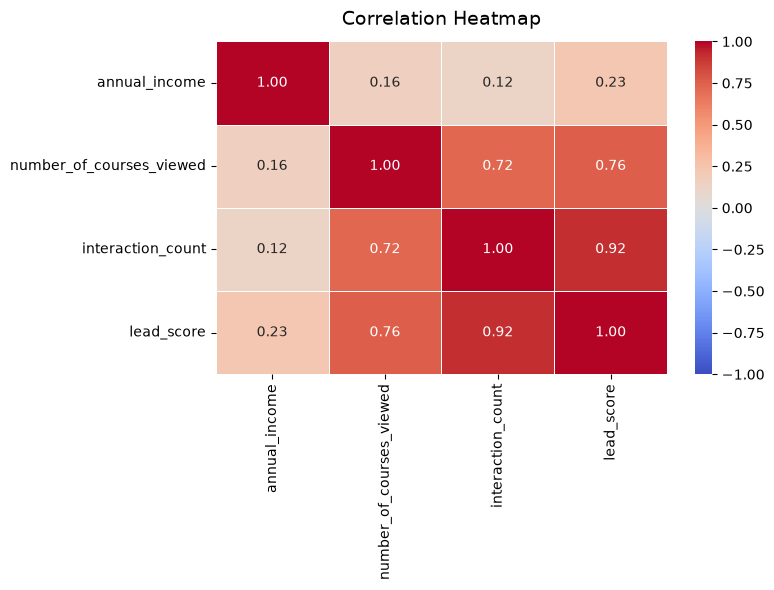

In [16]:
# Full correlation using correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Display numerical correlation values inside cells
    fmt=".2f",        # Round values to 2 decimal places
    cmap='coolwarm',  # Color palette (blue = negative, red = positive)
    vmin=-1, vmax=1,  # Anchor color scale between -1 and 1
    linewidths=0.5    # Add subtle grid lines between cells
)

plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### Split the data

- Split the data with these exact calls:

```python
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
```

- Make sure that the target value `converted` is not in your dataframe.

In [18]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [20]:
display(df_train.head())
df_train.info()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,employed,asia,65980.0,2,3,0.37
1,events,finance,employed,south_america,71662.0,0,0,0.09
2,referral,NA,employed,asia,40220.0,2,5,0.55
3,organic_search,finance,employed,north_america,88352.0,2,2,0.45
4,events,technology,employed,north_america,89316.0,1,5,0.00


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               3000 non-null   str    
 1   industry                  3000 non-null   str    
 2   employment_status         3000 non-null   str    
 3   location                  3000 non-null   str    
 4   annual_income             3000 non-null   float64
 5   number_of_courses_viewed  3000 non-null   int64  
 6   interaction_count         3000 non-null   int64  
 7   lead_score                3000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 187.6 KB


#### Q3. Biggest MI
- Calculate the mutual information score between `converted` and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?
- `industry`
- `location`
- `lead_source`
- `employment_status`

In [21]:
from sklearn.metrics import mutual_info_score

def calculate_mi(series):
    return mutual_info_score(series, y_train)

mi_scores = df_train[categorical].apply(calculate_mi).sort_values(ascending=False)
print(mi_scores.round(2))

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64


Mutual information measures how much information a feature provides about the target variable. A higher score indicates greater predictive importance. With a score of `0.03`, `lead_source` provides the most information about whether a lead will convert

#### Q4. Accuracy
- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
  - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
  - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

In [22]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)
orig_val_acc = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {round(orig_val_acc, 2)}")

Validation Accuracy: 0.65


#### Q5. Feature selection
- Let's find the least useful feature using the _feature elimination_ technique.
- Train a model using the same features and parameters as in Q4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

- `'lead_source'`
- `'number_of_courses_viewed'`
- `'interaction_count'`

> **Note**: The difference doesn't have to be positive.

In [23]:
all_features = categorical + numerical
q5_candidates = ['lead_source', 'number_of_courses_viewed', 'interaction_count']

for feature in q5_candidates:
    subset = [f for f in all_features if f != feature]
    
    tr_d = df_train[subset].to_dict(orient='records')
    v_d = df_val[subset].to_dict(orient='records')
    
    dv_sub = DictVectorizer(sparse=False)
    X_tr_sub = dv_sub.fit_transform(tr_d)
    X_v_sub = dv_sub.transform(v_d)
    
    m_sub = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    m_sub.fit(X_tr_sub, y_train)
    
    acc_sub = accuracy_score(y_val, m_sub.predict(X_v_sub))
    diff = orig_val_acc - acc_sub
    print(f"Without '{feature}': Acc = {acc_sub:.4f}, Diff = {diff:.6f}")

Without 'lead_source': Acc = 0.6420, Diff = 0.003000
Without 'number_of_courses_viewed': Acc = 0.6430, Diff = 0.002000
Without 'interaction_count': Acc = 0.6010, Diff = 0.044000


Since `0.002000 < 0.003000 < 0.044000`, removing `number_of_courses_viewed` had the least impact on model accuracy, identifying it as the least impactful feature among the choices.

#### Q6. Parameter tuning
- Now let's train a regularized logistic regression.
- Let's try the following values of the parameter `C`: `[0.000001, 0.00001, 0.0001, 0.001]`.
- Train models using all the features as in Q4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

- 0.000001
- 0.00001
- 0.0001
- 0.001

> **Note**: If there are multiple options, select the smallest `C`.

In [24]:
c_list = [0.000001, 0.00001, 0.0001, 0.001]

for c in c_list:
    m_c = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    m_c.fit(X_train, y_train)
    acc_c = accuracy_score(y_val, m_c.predict(X_val))
    print(f"C = {c:8f} -> Val Accuracy: {round(acc_c, 3)}")

C = 0.000001 -> Val Accuracy: 0.598
C = 0.000010 -> Val Accuracy: 0.598
C = 0.000100 -> Val Accuracy: 0.613
C = 0.001000 -> Val Accuracy: 0.645


**Result**: **C = 0.001**: **0.645** *(Highest validation accuracy)*